# Notebook 5 — Apprentissage Fédéré XGBoost (Entraînement Séquentiel + Soft Voting)

## Architecture fédérée

| Composant | Détail |
|-----------|--------|
| Modèle local | XGBoost `multi:softprob` (4 classes) |
| Stratégie | **Entraînement séquentiel** + **Soft Voting pondéré** |
| Clients | 5 (round-robin SubjectID — chacun a les 4 classes) |
| Données locales | train + val combinés |
| Modèle global | Enrichi séquentiellement par tous les clients à chaque round |
| Métrique | Log Loss multiclasse |

## Protocole par round

```
Round k :
  1. Ordre des clients mélangé aléatoirement (seed = 42 + k)
  2. Chaque client : xgb.train() depuis global_bst courant -> global_bst mis à jour immédiatement
  3. Serveur       : p_global = Σ (n_i/N) * p_i — soft voting sur les modèles finaux
  4. Serveur       : évalue p_global -> log_loss, accuracy, f1
  5. Répéter pour le round k+1
```

Après 100 rounds × 5 clients × 1 arbre = **500 arbres**, le modèle global a intégré
les données de tous les clients à chaque étape.

---

## 1. Imports & Configuration

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
import sys

sys.path.append('../src')

import xgboost as xgb

from task import (
    load_data,  get_test_dmatrix, 
    XGBOOST_PARAMS,  NUM_LOCAL_ROUNDS,  NUM_CLIENTS
)
from client_app import create_clients
from server_app import (
    run_federated,  soft_voting, 
    MODELS_PATH
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    log_loss, accuracy_score, f1_score
)

plt.style.use('seaborn-v0_8-whitegrid'); sns.set_palette('Set2')

FIGURES_PATH     = Path('../results/figures')
METRICS_PATH     = Path('../results/metrics')
SUBMISSIONS_PATH = Path('../data/submission')
for p in [FIGURES_PATH, METRICS_PATH, SUBMISSIONS_PATH]: p.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')
print(f'   Clients : {NUM_CLIENTS}')


✅ Imports OK
   Clients : 5


## 2. Chargement des données

In [2]:
train_df, val_df, test_df, feature_cols, le = load_data()
CLASSES = list(le.classes_)

print(f'Train  : {train_df.shape}  |  Val : {val_df.shape}  |  Test : {test_df.shape}')
print(f'Features : {len(feature_cols)}')
print(f'Classes  : {CLASSES}')
print(f'Sujets train : {train_df["SubjectID"].nunique()}')


Train  : (2463, 208)  |  Val : (438, 208)  |  Test : (1068, 205)
Features : 204
Classes  : ['Mouth', 'Nasal', 'Skin', 'Stool']
Sujets train : 54


## 3. Création des clients

Partitionnement **round-robin par SubjectID** sur train + val combinés.  
Chaque client a les 4 classes → prédictions valides sur toutes les classes.

In [3]:
clients = create_clients(
    train_df, val_df, feature_cols, le,
    params=XGBOOST_PARAMS,
    num_local_rounds=NUM_LOCAL_ROUNDS,
    n_clients=NUM_CLIENTS,
)


Création des clients (5 — train+val, round-robin SubjectID) :
  Client 0 : 14 sujets |  561 échantillons | 4 classes
  Client 1 : 13 sujets |  551 échantillons | 4 classes
  Client 2 : 13 sujets |  353 échantillons | 4 classes
  Client 3 : 13 sujets |  559 échantillons | 4 classes
  Client 4 : 13 sujets |  877 échantillons | 4 classes


## 4. Distribution des données par client

In [4]:
full_df  = pd.concat([train_df, val_df], ignore_index=True)
subjects = sorted(full_df['SubjectID'].unique())

client_stats = []
for i in range(NUM_CLIENTS):
    c_subj = [s for j,s in enumerate(subjects) if j%NUM_CLIENTS==i] # partitionnement round-robin par SubjectID
    c_data = full_df[full_df['SubjectID'].isin(c_subj)]
    stats  = {'Client': f'Client {i}', 'Sujets': len(c_subj), 'Échantillons': len(c_data)}

    for st in CLASSES: stats[st] = (c_data['SampleType']==st).sum()
    client_stats.append(stats)

stats_df = pd.DataFrame(client_stats)
stats_df


,Client,Sujets,Échantillons,Mouth,Nasal,Skin,Stool
0,Client 0,14,561,116,143,164,138
1,Client 1,13,551,129,132,162,128
2,Client 2,13,353,72,95,91,95
3,Client 3,13,559,123,134,168,134
4,Client 4,13,877,153,206,202,316


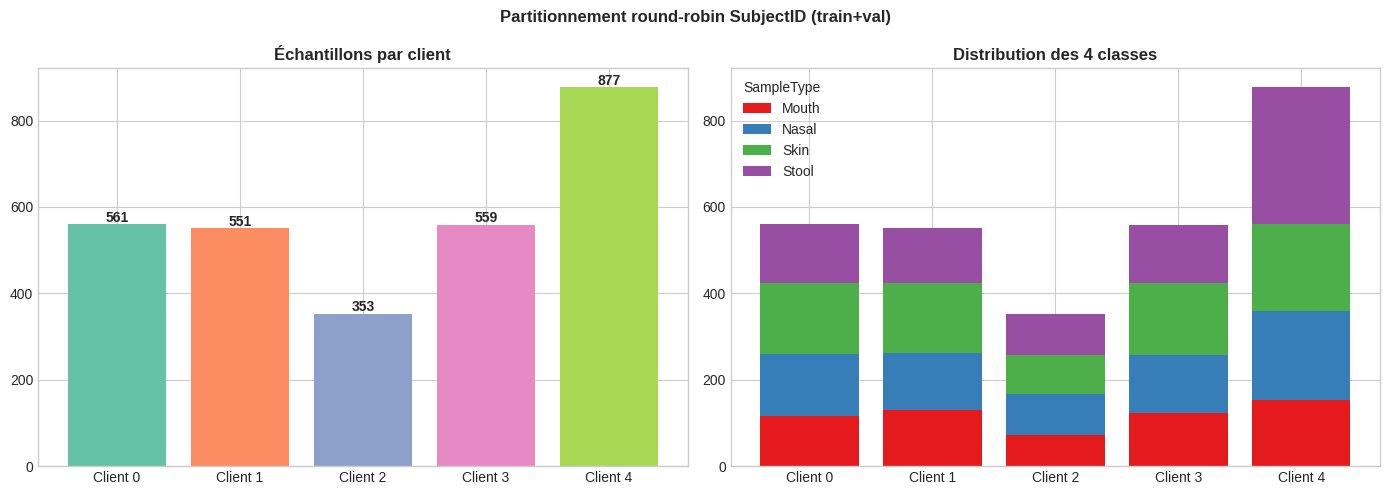

In [5]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
colors = sns.color_palette('Set2', NUM_CLIENTS)

# Barplot du nombre d'échantillons par client
bars = axes[0].bar(stats_df['Client'], stats_df['Échantillons'], color=colors)
axes[0].set_title('Échantillons par client', fontweight='bold')

# Annoter le nombre d'échantillons au-dessus de chaque barre
for bar, n in zip(bars, stats_df['Échantillons']):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+5, str(n), ha='center', fontweight='bold')

# Barplot empilé de la distribution des classes par client    
bottom = np.zeros(NUM_CLIENTS)
for cls, col in zip(CLASSES, sns.color_palette('Set1', 4)):
    vals = stats_df[cls].values
    axes[1].bar(stats_df['Client'], vals, bottom=bottom, label=cls, color=col)
    bottom += vals
axes[1].set_title('Distribution des 4 classes', fontweight='bold')
axes[1].legend(title='SampleType')

plt.suptitle('Partitionnement round-robin SubjectID (train+val)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH/'05_client_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Configuration paramètres fédération et XGBoost

In [6]:
NUM_ROUNDS = 100  # 100 rounds × 5 arbres/round = 500 arbres (idem centralisé)

print('Configuration :')
print(f'  Rounds FL              : {NUM_ROUNDS}')
print(f'  Clients / round        : {NUM_CLIENTS}')
print(f'  Arbres / client / round: {NUM_LOCAL_ROUNDS}')
print(f'  Arbres total (global)  : {NUM_ROUNDS * NUM_LOCAL_ROUNDS * NUM_CLIENTS}')
print(f'  Agrégation             : Soft Voting pondéré')
print()
for k, v in XGBOOST_PARAMS.items():
    print(f'  {k:<22} : {v}')


Configuration :
  Rounds FL              : 100
  Clients / round        : 5
  Arbres / client / round: 1
  Arbres total (global)  : 500
  Agrégation             : Soft Voting pondéré

  objective              : multi:softprob
  num_class              : 4
  eval_metric            : mlogloss
  eta                    : 0.05
  max_depth              : 6
  subsample              : 0.8
  colsample_bytree       : 0.8
  min_child_weight       : 1
  tree_method            : hist
  nthread                : 8
  seed                   : 42


## 6. Simulation fédérée

In [7]:
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

best_bst, fed_history = run_federated(clients, n_rounds=NUM_ROUNDS)

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')


⏰ Début : 13:50:33

SIMULATION FÉDÉRÉE — Entraînement Séquentiel + Soft Voting
  Clients    : 5
  Rounds     : 100
  Stratégie  : séquentiel (ordre mélangé chaque round)
  Agrégation : Soft Voting pondéré par n_samples

── Round 1/100 ──────────────────────────
  Client 4 | R 1 |  877 samples | LogLoss=1.3309 | Acc=0.2237 | Arbres=1
  Client 1 | R 1 |  551 samples | LogLoss=1.2428 | Acc=0.2237 | Arbres=2
  Client 2 | R 1 |  353 samples | LogLoss=1.1660 | Acc=0.2237 | Arbres=3
  Client 0 | R 1 |  561 samples | LogLoss=1.0942 | Acc=0.7078 | Arbres=4
  Client 3 | R 1 |  559 samples | LogLoss=1.0307 | Acc=0.9110 | Arbres=5
  -> Global | LogLoss=1.1833 | Acc=0.2237 | F1=0.0914 | Arbres=5
  🏆 Nouveau meilleur LogLoss : 1.1833
── Round 2/100 ──────────────────────────
  Client 2 | R 2 |  353 samples | LogLoss=0.9755 | Acc=0.9429 | Arbres=6
  Client 3 | R 2 |  559 samples | LogLoss=0.9220 | Acc=0.9521 | Arbres=7
  Client 0 | R 2 |  561 samples | LogLoss=0.8712 | Acc=0.9749 | Arbres=8
  Client 

## 7. Résultats par round

In [8]:
history_df = pd.read_csv(METRICS_PATH / 'federated_metrics.csv')
best_round = history_df.loc[history_df['log_loss'].idxmin()]

display(history_df.round(4))
print(f'\n🏆 Meilleur round : {int(best_round["round"])}')
print(f'   Log Loss : {best_round["log_loss"]:.4f}')
print(f'   Accuracy : {best_round["accuracy"]:.4f}')
print(f'   F1-macro : {best_round["f1_macro"]:.4f}')


,round,log_loss,accuracy,f1_macro,n_trees
0,1,1.1833,0.2237,0.0914,5
1,2,0.8595,0.9726,0.9716,10
2,3,0.6517,0.9886,0.9889,15
3,4,0.5112,0.9909,0.9910,20
4,5,0.4023,0.9909,0.9910,25
...,...,...,...,...,...
95,96,0.0078,0.9977,0.9978,480
96,97,0.0077,0.9977,0.9978,485
97,98,0.0077,0.9977,0.9978,490
98,99,0.0076,0.9977,0.9978,495



🏆 Meilleur round : 100
   Log Loss : 0.0076
   Accuracy : 0.9977
   F1-macro : 0.9978


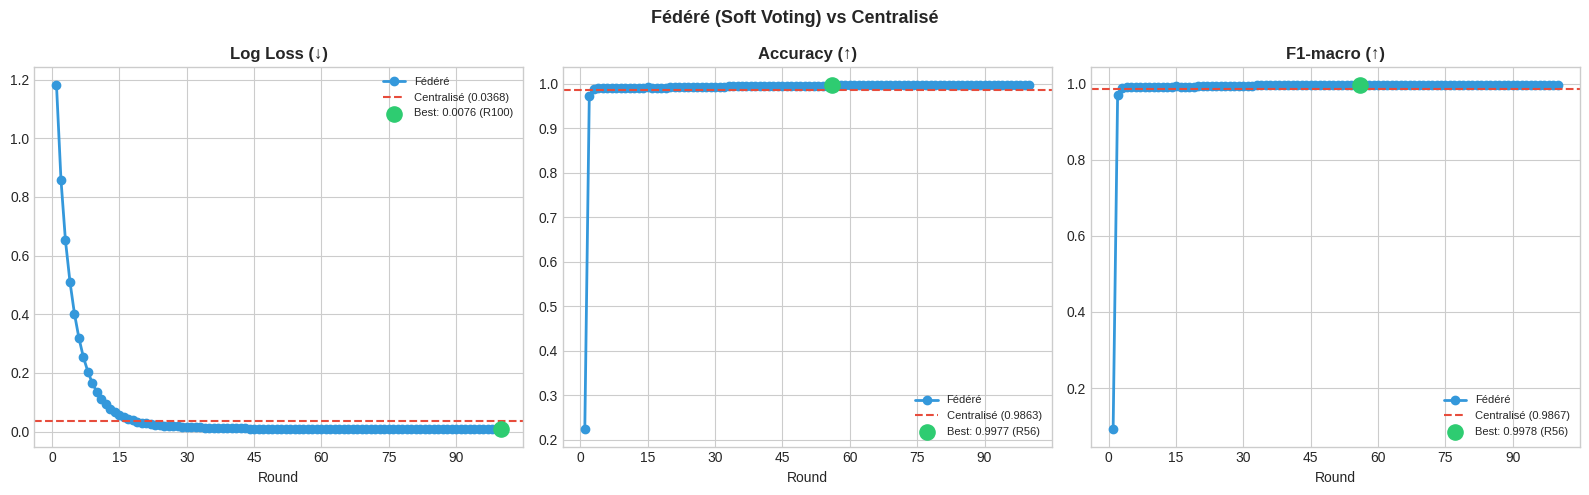

In [9]:
centralized_path = METRICS_PATH / 'centralized_metrics.csv'
best_cen = pd.read_csv(centralized_path).sort_values('log_loss').iloc[0] \
    if centralized_path.exists() else None

fig, axes = plt.subplots(1,3, figsize=(16,5))
for ax, metric, title, better in zip(
    axes,
    ['log_loss','accuracy','f1_macro'],
    ['Log Loss (↓)','Accuracy (↑)','F1-macro (↑)'],
    ['min','max','max']
):
    ax.plot(history_df['round'], history_df[metric],'o-',
            color='#3498db', lw=2, ms=6, label='Fédéré')
    if best_cen is not None and metric in best_cen.index:
        ref = best_cen[metric]
        ax.axhline(ref, color='#e74c3c', ls='--', lw=1.5,
                   label=f'Centralisé ({ref:.4f})')
    bi = history_df[metric].idxmin() if better=='min' else history_df[metric].idxmax()
    bv = history_df.loc[bi,metric]; br = history_df.loc[bi,'round']
    ax.scatter([br],[bv], color='#2ecc71', s=120, zorder=5,
               label=f'Best: {bv:.4f} (R{int(br)})')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Round')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

plt.suptitle('Fédéré (Soft Voting) vs Centralisé', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH/'05_federated_metrics_per_round.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Évaluation du meilleur modèle global

Arbres : 500
Log Loss : 0.0076
Accuracy : 0.9977
F1-macro : 0.9978

              precision    recall  f1-score   support

       Mouth       0.99      1.00      1.00       100
       Nasal       1.00      1.00      1.00       103
        Skin       1.00      0.99      1.00       137
       Stool       1.00      1.00      1.00        98

    accuracy                           1.00       438
   macro avg       1.00      1.00      1.00       438
weighted avg       1.00      1.00      1.00       438



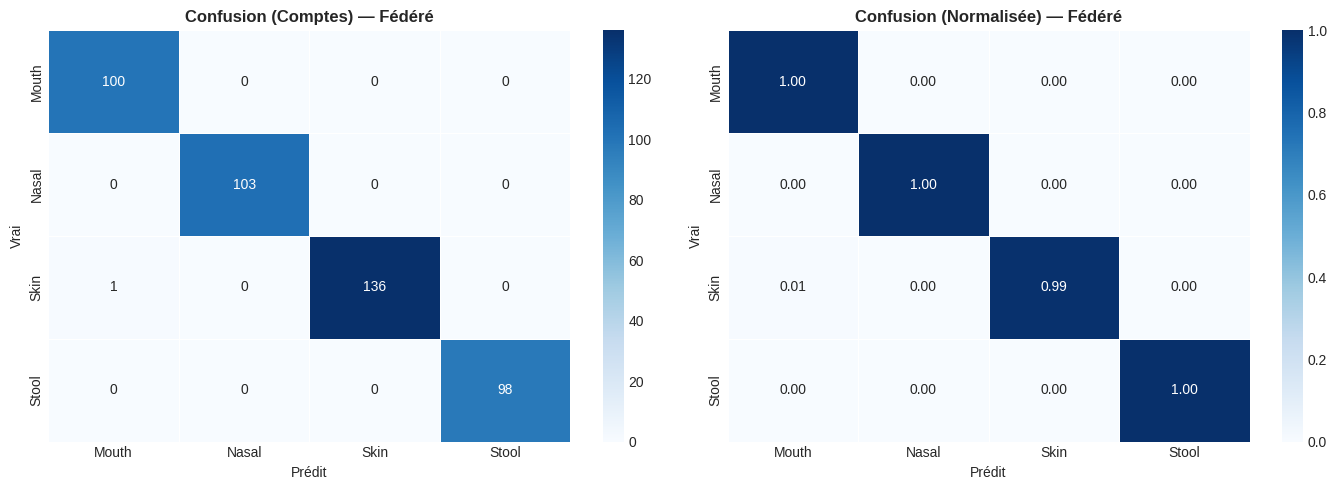

In [10]:
# Charger le meilleur modèle
best_bst_loaded = xgb.Booster()
best_bst_loaded.load_model(str(MODELS_PATH / 'best_global_model.ubj'))
print(f'Arbres : {best_bst_loaded.num_boosted_rounds()}')

# Recalculer les probas du meilleur round avec soft voting
X_val    = val_df[feature_cols].values
y_val    = le.transform(val_df['SampleType'].values)
val_dmat = xgb.DMatrix(X_val, label=y_val)

# Soft voting final avec tous les clients entraînés
all_probas  = [c.bst.predict(val_dmat).reshape(-1,len(CLASSES))
               for c in clients if c.bst is not None]
all_weights = [c.n_train for c in clients if c.bst is not None]
final_proba = soft_voting(all_probas, all_weights)

y_pred = final_proba.argmax(axis=1)
print(f'Log Loss : {log_loss(y_val, final_proba, labels=list(range(len(CLASSES)))):.4f}')
print(f'Accuracy : {accuracy_score(y_val, y_pred):.4f}')
print(f'F1-macro : {f1_score(y_val, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_val, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax,data,fmt,t in zip(axes,[cm,cm_norm],['d','.2f'],['Comptes','Normalisée']):
    sns.heatmap(data, annot=True, fmt=fmt, xticklabels=CLASSES,
                yticklabels=CLASSES, cmap='Blues', ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion ({t}) — Fédéré', fontweight='bold')
    ax.set_ylabel('Vrai'); ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig(FIGURES_PATH/'05_confusion_matrix_federated.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Comparaison Fédéré vs Centralisé

  Métrique       |   Fédéré | Centralisé | Δ
  --------------------------------------------------
  log_loss       |   0.0076 |     0.0368 | -0.0292
  accuracy       |   0.9977 |     0.9863 | +0.0114
  f1_macro       |   0.9978 |     0.9867 | +0.0112


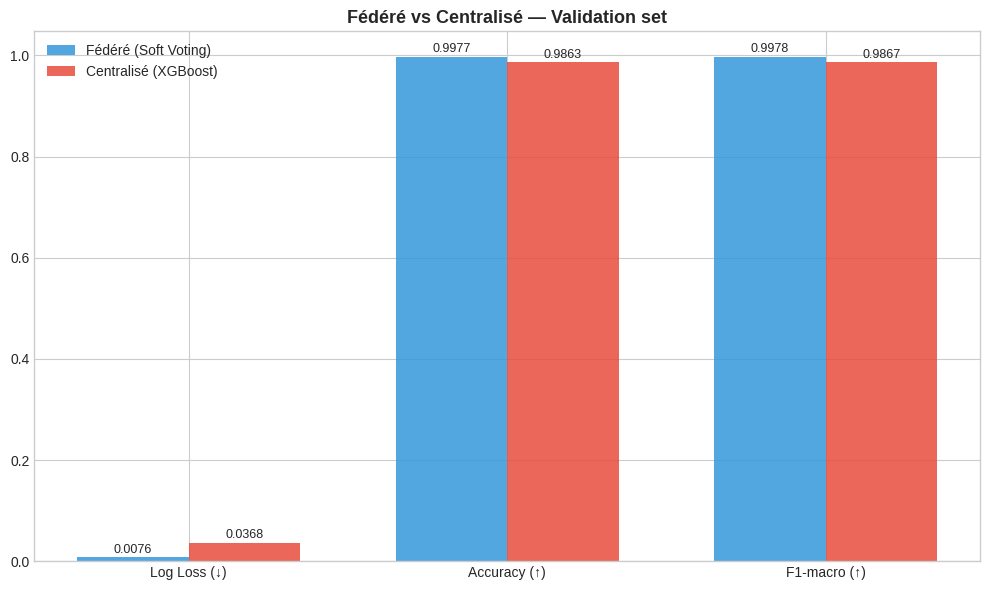

In [11]:
if best_cen is not None:
    metrics_fed = {
        'log_loss': float(log_loss(y_val, final_proba, labels=list(range(len(CLASSES))))),
        'accuracy': float(accuracy_score(y_val, y_pred)),
        'f1_macro': float(f1_score(y_val, y_pred, average='macro')),
    }
    print('='*55)
    print(f'  {"Métrique":<14} | {"Fédéré":>8} | {"Centralisé":>10} | Δ')
    print(f'  {"-"*50}')
    for m in ['log_loss','accuracy','f1_macro']:
        fv=metrics_fed[m]; cv=best_cen[m]; d=fv-cv
        print(f'  {m:<14} | {fv:>8.4f} | {cv:>10.4f} | {"+" if d>0 else ""}{d:.4f}')
    print('='*55)

    ml=['log_loss','accuracy','f1_macro']
    tl=['Log Loss (↓)','Accuracy (↑)','F1-macro (↑)']
    x=np.arange(len(ml)); w=0.35
    fig, ax = plt.subplots(figsize=(10,6))
    b1=ax.bar(x-w/2,[metrics_fed[m] for m in ml],w,
              label='Fédéré (Soft Voting)',color='#3498db',alpha=0.85)
    b2=ax.bar(x+w/2,[best_cen[m] for m in ml],w,
              label=f'Centralisé ({best_cen["model"]})',color='#e74c3c',alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(tl)
    ax.set_title('Fédéré vs Centralisé — Validation set',fontweight='bold',fontsize=13)
    ax.legend()
    for bar in [*b1,*b2]:
        ax.text(bar.get_x()+bar.get_width()/2.,bar.get_height()+0.003,
                f'{bar.get_height():.4f}',ha='center',va='bottom',fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH/'05_federated_vs_centralized.png',dpi=150,bbox_inches='tight')
    plt.show()


## 10. Calibration en température

Le log_loss est sensible à la **confiance** des probabilités.  
La calibration en température trouve un scalaire T tel que :

```
p_cal(x) = softmax(log(p(x)) / T)
```

- T < 1 → probabilités plus tranchées (plus confiantes)
- T > 1 → probabilités plus douces (moins confiantes)

T est optimisé sur le val set (grid search borné) puis appliqué au test.

In [12]:
from scipy.optimize import minimize_scalar
from scipy.special import softmax as scipy_softmax

def apply_temperature(proba: np.ndarray, T: float) -> np.ndarray:
    log_p = np.log(np.clip(proba, 1e-10, 1.0))
    return scipy_softmax(log_p / T, axis=1)

# ── Calibration en température sur le val set ────────────────────────────────
X_val    = val_df[feature_cols].values
y_val    = le.transform(val_df['SampleType'].values)
val_dmat = xgb.DMatrix(X_val, label=y_val)

val_probas_raw  = [c.bst.predict(val_dmat).reshape(-1, len(CLASSES))
                   for c in clients if c.bst is not None]
val_weights_raw = [c.n_train for c in clients if c.bst is not None]
val_proba_raw   = soft_voting(val_probas_raw, val_weights_raw)

result = minimize_scalar(
    lambda T: log_loss(y_val, apply_temperature(val_proba_raw, T),
                       labels=list(range(len(CLASSES)))),
    bounds=(0.1, 5.0), method='bounded'
)
T_opt = result.x
print(f'Température optimale : T = {T_opt:.4f}')
print(f'Log Loss brut        : {log_loss(y_val, val_proba_raw):.4f}')
print(f'Log Loss calibré     : {result.fun:.4f}')

# ── Prédictions test calibrées ───────────────────────────────────────────────
test_dmat        = get_test_dmatrix(test_df, feature_cols)
test_probas      = [c.bst.predict(test_dmat).reshape(-1, len(CLASSES))
                    for c in clients if c.bst is not None]
test_weights     = [c.n_train for c in clients if c.bst is not None]
y_test_proba_raw = soft_voting(test_probas, test_weights)
y_test_proba     = apply_temperature(y_test_proba_raw, T_opt)



Température optimale : T = 0.6644
Log Loss brut        : 0.0076
Log Loss calibré     : 0.0057


## 11. Soumission Zindi

In [13]:
sample_sub    = pd.read_csv('../data/submission/SampleSubmission.csv')
COLS    = sample_sub.columns.tolist()
CLASSES = COLS[1:]

proba_df = pd.DataFrame(y_test_proba, columns=CLASSES)
proba_df.insert(0, 'filename', test_df['filename'].values)

submission = sample_sub[['filename']].merge(proba_df, on='filename', how='left')
n_missing  = submission[CLASSES[0]].isnull().sum()
if n_missing > 0:
    for cls in CLASSES: submission[cls] = submission[cls].fillna(1 / len(CLASSES))
    print(f'⚠️  {n_missing} manquant(s) -> uniforme')

submission['filename'] = submission['filename'].str.replace('.mgb', '', regex=False)
submission = submission[COLS]

assert len(submission) == len(sample_sub)
assert submission.isnull().sum().sum() == 0
assert (submission[CLASSES].sum(axis=1) - 1.0).abs().max() < 1e-5

sub_path = SUBMISSIONS_PATH / 'submission_federated.csv'
submission.to_csv(sub_path, index=False)
print(f'✅ Soumission : {sub_path}')
display(submission.head(3))

✅ Soumission : ../data/submission/submission_federated.csv


,filename,Mouth,Nasal,Skin,Stool
0,ID_YBNOYC,8.565221e-08,0.999998,5.376982e-07,0.000001
1,ID_HPVLUO,4.887489e-07,0.000007,1.021155e-07,0.999992
2,ID_DQGGYD,1.514088e-05,0.999546,4.354939e-04,0.000003


## Résumé du Notebook 5

| Paramètre | Valeur |
|-----------|--------|
| Stratégie | Soft Voting pondéré |
| Clients | 5 (round-robin SubjectID, train+val) |
| Rounds | 20 |
| Modèle | XGBoost `multi:softprob` |
| **Log Loss fédéré** | — |
| **Log Loss centralisé** | — |
